# Этап 4. Градиентный бустинг

В этом ноутбуке рассматривается последовательное построение ансамбля с помощью градиентного бустинга.  
В отличие от Bagging и Random Forest, где деревья обучаются параллельно, бустинг строит деревья последовательно: каждая следующая модель исправляет ошибки предыдущих.

## 4.1. Импорт библиотек и загрузка данных

Используем уже подготовленные датасеты из первого этапа:

- `train_one_hot_encoded.csv`;
- `validation_one_hot_encoded.csv`;
- `test_one_hot_encoded.csv`.

Целевая переменная `charges` в этих файлах уже логарифмирована через `log1p`, а исходная шкала сохранена в `charges_original`.

In [1]:
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import KFold, RandomizedSearchCV
from sklearn.metrics import make_scorer
from sklearn.metrics import (
    mean_absolute_error as sklearn_mean_absolute_error,
    root_mean_squared_error as sklearn_root_mean_squared_error,
    r2_score as sklearn_r2_score
)

cwd = Path.cwd()

if (cwd / 'data' / 'processed').exists():
    project_dir = cwd
elif (cwd.parent / 'data' / 'processed').exists():
    project_dir = cwd.parent
else:
    project_dir = Path('..')

processed_dir = project_dir / 'data' / 'processed'
models_dir = project_dir / 'models'
figures_dir = project_dir / 'reports' / 'figures'

models_dir.mkdir(parents=True, exist_ok=True)
figures_dir.mkdir(parents=True, exist_ok=True)

train_df = pd.read_csv(processed_dir / 'train_one_hot_encoded.csv')
val_df = pd.read_csv(processed_dir / 'validation_one_hot_encoded.csv')
test_df = pd.read_csv(processed_dir / 'test_one_hot_encoded.csv')

target_col = 'charges'
original_target_col = 'charges_original'
feature_cols = [col for col in train_df.columns if col not in [target_col, original_target_col]]

X_train = train_df[feature_cols]
y_train = train_df[target_col]
y_train_original = train_df[original_target_col]

X_val = val_df[feature_cols]
y_val = val_df[target_col]
y_val_original = val_df[original_target_col]

X_test = test_df[feature_cols]
y_test = test_df[target_col]
y_test_original = test_df[original_target_col]

print('Тренировочная выборка:', X_train.shape)
print('Валидационная выборка:', X_val.shape)
print('Тестовая выборка:', X_test.shape)

Тренировочная выборка: (801, 8)
Валидационная выборка: (268, 8)
Тестовая выборка: (268, 8)


## 4.2. Метрики качества

Модель обучается на `log1p(charges)`, поэтому перед расчетом метрик предсказания нужно возвращать в исходную шкалу через `expm1`.

Используем:

- `R²` — доля объясненной дисперсии;
- `MAE` — средняя абсолютная ошибка;
- `RMSE` — корень из средней квадратичной ошибки, чувствителен к крупным ошибкам.

In [2]:
def inverse_target(values):
    return np.expm1(values)


def r2_original_scale(y_true_log, y_pred_log):
    return sklearn_r2_score(inverse_target(y_true_log), inverse_target(y_pred_log))


r2_original_scorer = make_scorer(r2_original_scale)


def r2_score(y_true_log, y_pred_log):
    return r2_original_scale(y_true_log, y_pred_log)


def mean_absolute_error(y_true_log, y_pred_log):
    return sklearn_mean_absolute_error(inverse_target(y_true_log), inverse_target(y_pred_log))


def root_mean_squared_error(y_true_log, y_pred_log):
    return sklearn_root_mean_squared_error(inverse_target(y_true_log), inverse_target(y_pred_log))


def print_metrics(y_true_log, y_pred_log, title):
    print(title)
    print(f"R2:   {r2_score(y_true_log, y_pred_log):.4f}")
    print(f"MAE:  ${mean_absolute_error(y_true_log, y_pred_log):.2f}")
    print(f"RMSE: ${root_mean_squared_error(y_true_log, y_pred_log):.2f}")

## 4.3. Идея градиентного бустинга

Градиентный бустинг строит ансамбль последовательно:

1. Первая модель делает начальное приближение.
2. Затем считаются ошибки текущего ансамбля.
3. Новое дерево обучается исправлять эти ошибки.
4. Итоговый прогноз получается как сумма вкладов всех деревьев.

В задачах регрессии это можно понимать как постепенное движение в сторону уменьшения функции потерь. В этом смысле бустинг похож на градиентный спуск, только шаги делаются не по отдельным коэффициентам, а в пространстве функций.

## 4.4. Псевдо-остатки

Псевдо-остатки — это направление, в котором нужно исправлять текущие предсказания ансамбля.

Для квадратичной ошибки они близки к обычным остаткам:

`факт - прогноз`

На каждом шаге бустинг обучает новое дерево так, чтобы оно предсказывало эти остатки. Поэтому каждое следующее дерево не решает задачу с нуля, а исправляет ошибки уже построенного ансамбля.

## 4.5. Базовая модель GradientBoostingRegressor

Сначала обучим модель с параметрами по умолчанию. Это даст базовую точку отсчета перед подбором гиперпараметров.

In [3]:
gb_baseline = GradientBoostingRegressor(random_state=42)
gb_baseline.fit(X_train, y_train)

gb_val_pred_baseline = gb_baseline.predict(X_val)

print_metrics(
    y_val,
    gb_val_pred_baseline,
    'Базовый GradientBoostingRegressor на валидационной выборке'
)

Базовый GradientBoostingRegressor на валидационной выборке
R2:   0.8655
MAE:  $2235.64
RMSE: $4525.11


## 4.6. Основные гиперпараметры бустинга

В градиентном бустинге особенно важны:

- `n_estimators` — количество деревьев в ансамбле;
- `learning_rate` — размер шага, с которым добавляется новое дерево;
- `max_depth` — глубина каждого отдельного дерева;
- `min_samples_split` и `min_samples_leaf` — ограничения на разбиения и листья;
- `subsample` — доля объектов для обучения каждого дерева;
- `max_features` — число признаков, доступных при построении разбиений.

Обычно маленький `learning_rate` требует большего числа деревьев, но может давать более устойчивую модель.

## 4.7. Двухэтапный подбор гиперпараметров через RandomizedSearchCV

Для бустинга сетка параметров может быть большой, поэтому используем двухэтапный подход.

Сначала выполняется широкий поиск по разным областям параметров. Затем строится уточненный поиск рядом с лучшими найденными значениями. Так мы не перебираем все возможные комбинации, но проверяем перспективную область подробнее.

In [4]:
gb_cv = KFold(n_splits=5, shuffle=True, random_state=42)

gb_coarse_param_distributions = {
    'n_estimators': [100, 150, 200, 300, 500, 700],
    'learning_rate': [0.01, 0.03, 0.05, 0.07, 0.1],
    'max_depth': [2, 3, 4, 5],
    'min_samples_split': [2, 5, 10, 20, 40],
    'min_samples_leaf': [1, 2, 4, 8, 12],
    'subsample': [0.6, 0.8, 1.0],
    'max_features': [None, 'sqrt', 0.7, 1.0]
}

gb_coarse_random_search = RandomizedSearchCV(
    estimator=GradientBoostingRegressor(random_state=42),
    param_distributions=gb_coarse_param_distributions,
    n_iter=60,
    scoring=r2_original_scorer,
    cv=gb_cv,
    random_state=42,
    n_jobs=-1,
    return_train_score=True
)

gb_coarse_random_search.fit(X_train, y_train)
gb_coarse_best_params = gb_coarse_random_search.best_params_

print('Лучшие параметры после широкого поиска:')
print(gb_coarse_best_params)
print(f"Лучший средний R2 после широкого поиска: {gb_coarse_random_search.best_score_:.4f}")

def integer_values_around(best_value, radius, lower_bound, upper_bound):
    values = range(best_value - radius, best_value + radius + 1)
    return [int(value) for value in values if lower_bound <= value <= upper_bound]

def stepped_values_around(best_value, radius, step, lower_bound, upper_bound):
    values = range(best_value - radius, best_value + radius + 1, step)
    result = sorted({int(value) for value in values if lower_bound <= value <= upper_bound})
    if int(best_value) not in result:
        result.append(int(best_value))
    return sorted(result)

def float_values_around(best_value, radius, lower_bound, upper_bound):
    values = [best_value - radius, best_value, best_value + radius]
    return sorted({round(value, 3) for value in values if lower_bound <= value <= upper_bound})

best_learning_rate = gb_coarse_best_params['learning_rate']
best_max_features = gb_coarse_best_params['max_features']

if isinstance(best_max_features, str) or best_max_features is None:
    refined_max_features = [best_max_features, 0.7, 1.0]
else:
    refined_max_features = float_values_around(best_max_features, radius=0.1, lower_bound=0.4, upper_bound=1.0)

gb_refined_param_distributions = {
    'n_estimators': stepped_values_around(gb_coarse_best_params['n_estimators'], radius=100, step=50, lower_bound=50, upper_bound=900),
    'learning_rate': float_values_around(best_learning_rate, radius=0.02, lower_bound=0.005, upper_bound=0.2),
    'max_depth': integer_values_around(gb_coarse_best_params['max_depth'], radius=1, lower_bound=1, upper_bound=6),
    'min_samples_split': integer_values_around(gb_coarse_best_params['min_samples_split'], radius=3, lower_bound=2, upper_bound=60),
    'min_samples_leaf': integer_values_around(gb_coarse_best_params['min_samples_leaf'], radius=2, lower_bound=1, upper_bound=30),
    'subsample': float_values_around(gb_coarse_best_params['subsample'], radius=0.1, lower_bound=0.5, upper_bound=1.0),
    'max_features': refined_max_features
}

gb_refined_random_search = RandomizedSearchCV(
    estimator=GradientBoostingRegressor(random_state=42),
    param_distributions=gb_refined_param_distributions,
    n_iter=50,
    scoring=r2_original_scorer,
    cv=gb_cv,
    random_state=43,
    n_jobs=-1,
    return_train_score=True
)

gb_refined_random_search.fit(X_train, y_train)

# Дальше используем результат уточненного поиска.
gb_random_search = gb_refined_random_search

best_gb_cv = gb_random_search.best_estimator_
gb_val_pred = best_gb_cv.predict(X_val)

print('\nЛучшие параметры после уточненного поиска:')
print(gb_random_search.best_params_)
print(f"Лучший средний R2 после уточненного поиска: {gb_random_search.best_score_:.4f}")
print()
print_metrics(
    y_val,
    gb_val_pred,
    'Оптимизированный GradientBoostingRegressor на валидационной выборке'
)

gb_coarse_cv_results = pd.DataFrame(gb_coarse_random_search.cv_results_)
gb_cv_results = pd.DataFrame(gb_refined_random_search.cv_results_)
gb_cv_results[['mean_test_score', 'mean_train_score', 'params']].sort_values(
    by='mean_test_score',
    ascending=False
).head(10)

Лучшие параметры после широкого поиска:
{'subsample': 0.8, 'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 8, 'max_features': 1.0, 'max_depth': 3, 'learning_rate': 0.03}
Лучший средний R2 после широкого поиска: 0.8444

Лучшие параметры после уточненного поиска:
{'subsample': 0.9, 'n_estimators': 100, 'min_samples_split': 4, 'min_samples_leaf': 7, 'max_features': 1.0, 'max_depth': 3, 'learning_rate': 0.05}
Лучший средний R2 после уточненного поиска: 0.8448

Оптимизированный GradientBoostingRegressor на валидационной выборке
R2:   0.8719
MAE:  $2041.35
RMSE: $4415.52


,mean_test_score,mean_train_score,params
43,0.844752,0.874476,"{'subsample': 0.9, 'n_estimators': 100, 'min_s..."
25,0.844478,0.873090,"{'subsample': 0.9, 'n_estimators': 150, 'min_s..."
40,0.843347,0.871282,"{'subsample': 0.8, 'n_estimators': 150, 'min_s..."
12,0.842412,0.891699,"{'subsample': 0.9, 'n_estimators': 250, 'min_s..."
0,0.841085,0.870288,"{'subsample': 0.9, 'n_estimators': 100, 'min_s..."
41,0.841002,0.881938,"{'subsample': 0.9, 'n_estimators': 300, 'min_s..."
19,0.840667,0.878509,"{'subsample': 0.7, 'n_estimators': 150, 'min_s..."
34,0.840254,0.892480,"{'subsample': 0.9, 'n_estimators': 150, 'min_s..."
9,0.838407,0.882367,"{'subsample': 0.7, 'n_estimators': 200, 'min_s..."
49,0.835617,0.858467,"{'subsample': 0.8, 'n_estimators': 100, 'min_s..."


## 4.8. Финальная проверка на тестовой выборке

После выбора гиперпараметров обучаем лучшую модель на объединенных `Train + Validation` данных.  
Тестовая выборка используется только на финальном шаге.

In [5]:
X_train_full = pd.concat([X_train, X_val])
y_train_full = pd.concat([y_train, y_val])

best_gb = clone(gb_random_search.best_estimator_)
best_gb.fit(X_train_full, y_train_full)

gb_test_pred = best_gb.predict(X_test)

print_metrics(
    y_test,
    gb_test_pred,
    'Финальная проверка GradientBoostingRegressor на тестовой выборке'
)

joblib.dump(best_gb, models_dir / 'gradient_boosting_randomized_search_model.pkl')
print('Модель сохранена:', models_dir / 'gradient_boosting_randomized_search_model.pkl')

Финальная проверка GradientBoostingRegressor на тестовой выборке
R2:   0.8483
MAE:  $1938.55
RMSE: $4443.66
Модель сохранена: c:\Users\bulki\OneDrive\Документы\GitHub\Practice_DecisionTreeRegressor\models\gradient_boosting_randomized_search_model.pkl


## 4.9. Кривые обучения по числу деревьев

Посмотрим, как меняется качество модели при добавлении новых деревьев.  
Если качество на train продолжает расти, а на validation перестает улучшаться или падает, это признак переобучения.

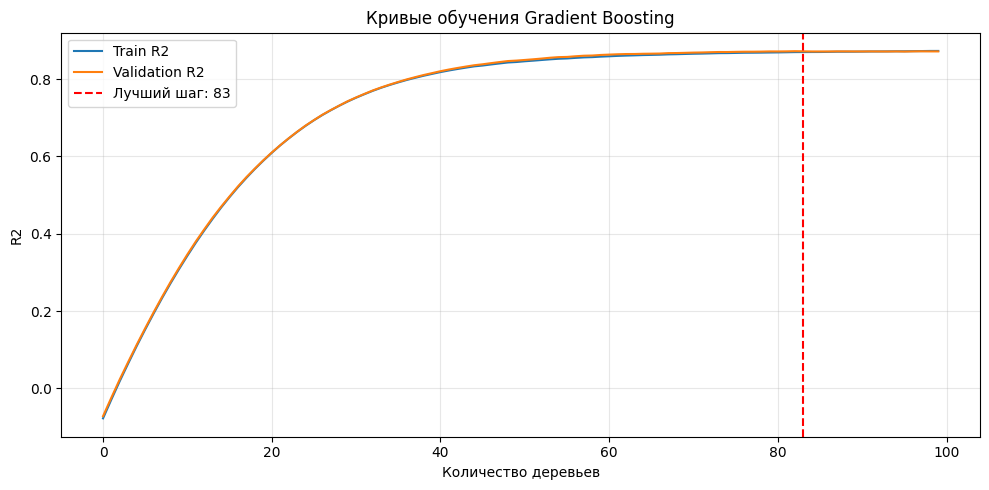

Лучшее количество деревьев по validation: 83
Лучший R2 на validation: 0.8725


In [6]:
gb_for_learning_curve = clone(gb_random_search.best_estimator_)
gb_for_learning_curve.fit(X_train, y_train)

train_r2_by_stage = []
val_r2_by_stage = []

for train_pred_stage, val_pred_stage in zip(
    gb_for_learning_curve.staged_predict(X_train),
    gb_for_learning_curve.staged_predict(X_val)
):
    train_r2_by_stage.append(r2_score(y_train, train_pred_stage))
    val_r2_by_stage.append(r2_score(y_val, val_pred_stage))

best_stage = int(np.argmax(val_r2_by_stage) + 1)
best_stage_score = max(val_r2_by_stage)

plt.figure(figsize=(10, 5))
plt.plot(train_r2_by_stage, label='Train R2')
plt.plot(val_r2_by_stage, label='Validation R2')
plt.axvline(best_stage, color='red', linestyle='--', label=f'Лучший шаг: {best_stage}')
plt.title('Кривые обучения Gradient Boosting')
plt.xlabel('Количество деревьев')
plt.ylabel('R2')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(figures_dir / 'gradient_boosting_learning_curve.png', dpi=200, bbox_inches='tight')
plt.show()

print(f"Лучшее количество деревьев по validation: {best_stage}")
print(f"Лучший R2 на validation: {best_stage_score:.4f}")

## 4.10. Анализ ошибок модели

Построим график остатков. Он показывает, есть ли у модели систематические ошибки и на каких значениях `charges` прогноз становится менее точным.

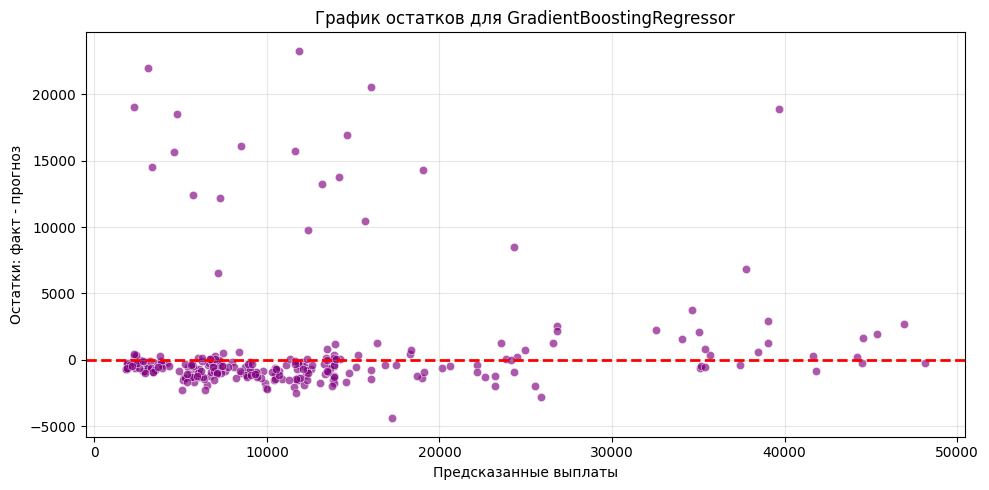

In [7]:
gb_residuals = inverse_target(y_test) - inverse_target(gb_test_pred)

plt.figure(figsize=(10, 5))
sns.scatterplot(x=inverse_target(gb_test_pred), y=gb_residuals, alpha=0.65, color='purple')
plt.axhline(y=0, color='red', linestyle='--', linewidth=2)
plt.title('График остатков для GradientBoostingRegressor')
plt.xlabel('Предсказанные выплаты')
plt.ylabel('Остатки: факт - прогноз')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(figures_dir / 'gradient_boosting_residuals_test.png', dpi=200, bbox_inches='tight')
plt.show()

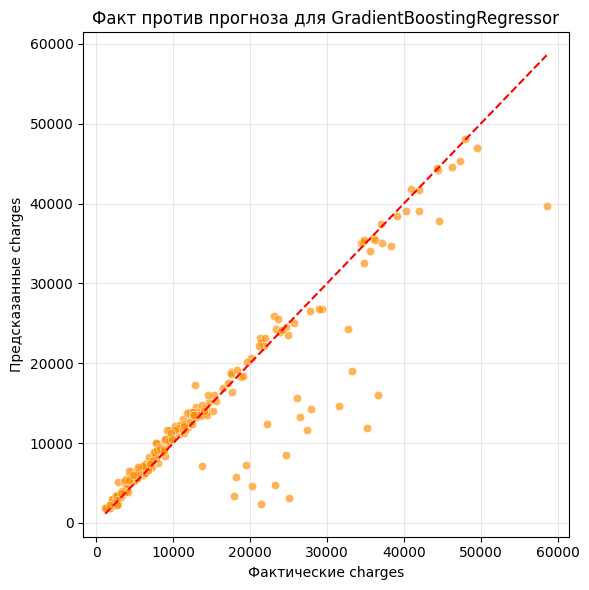

In [8]:
plt.figure(figsize=(6, 6))
sns.scatterplot(x=inverse_target(y_test), y=inverse_target(gb_test_pred), alpha=0.65, color='darkorange')
min_value = min(inverse_target(y_test).min(), inverse_target(gb_test_pred).min())
max_value = max(inverse_target(y_test).max(), inverse_target(gb_test_pred).max())
plt.plot([min_value, max_value], [min_value, max_value], color='red', linestyle='--')
plt.title('Факт против прогноза для GradientBoostingRegressor')
plt.xlabel('Фактические charges')
plt.ylabel('Предсказанные charges')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(figures_dir / 'gradient_boosting_actual_vs_predicted.png', dpi=200, bbox_inches='tight')
plt.show()

## 4.11. Важность признаков

Градиентный бустинг, как и другие модели на основе деревьев, позволяет оценить вклад признаков в построение предсказаний.

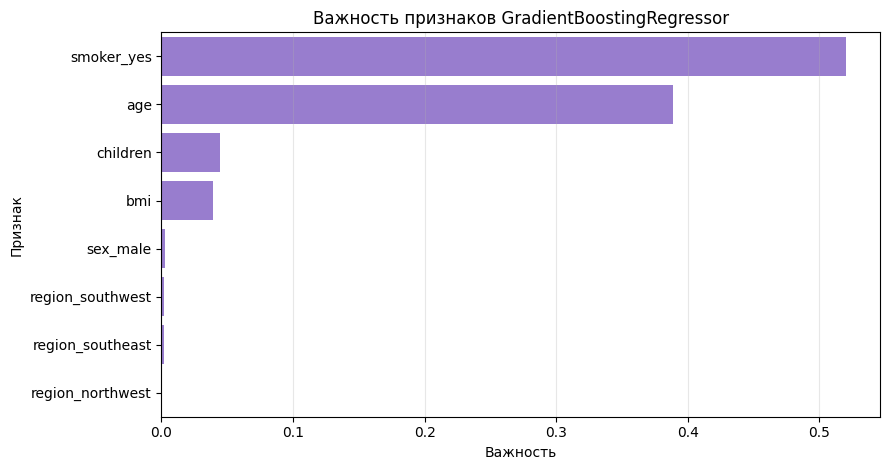

,Признак,Важность
4,smoker_yes,0.520111
0,age,0.389135
2,children,0.044194
1,bmi,0.039578
3,sex_male,0.002834
7,region_southwest,0.002200
6,region_southeast,0.001833
5,region_northwest,0.000115


In [9]:
gb_feature_importance_df = pd.DataFrame({
    'Признак': X_train.columns,
    'Важность': best_gb.feature_importances_
}).sort_values(by='Важность', ascending=False)

plt.figure(figsize=(9, 4.8))
sns.barplot(data=gb_feature_importance_df, x='Важность', y='Признак', color='mediumpurple')
plt.title('Важность признаков GradientBoostingRegressor')
plt.xlabel('Важность')
plt.ylabel('Признак')
plt.grid(True, axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(figures_dir / 'gradient_boosting_feature_importance.png', dpi=200, bbox_inches='tight')
plt.show()

gb_feature_importance_df

## 4.12. Вывод по этапу 4

Градиентный бустинг строит ансамбль последовательно: каждое новое дерево исправляет ошибки уже построенной композиции.  
В отличие от Bagging и Random Forest, где деревья обучаются независимо, бустинг постепенно улучшает общий прогноз.

На этом этапе:

1. Была обучена базовая модель `GradientBoostingRegressor`.
2. Выполнен подбор гиперпараметров через `RandomizedSearchCV`.
3. Лучшая модель проверена на отложенной тестовой выборке.
4. Построены кривые обучения, график остатков, график `факт против прогноза` и важность признаков.

Итоговое качество нужно сравнить с предыдущими моделями: одиночным деревом, Bagging и Random Forest. Если бустинг показывает меньший RMSE и более высокий R2, значит последовательное исправление ошибок оказалось полезнее простого усреднения деревьев.